# Shadow Variant Experiments via API


---

This notebook's CI test result for us-west-2 is as follows. CI test results in other regions can be found at the end of the notebook. 

![This us-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-2/deploy_and_monitor|sm-shadow_variant_shadow_api|sm-shadow_variant_shadow_api.ipynb)

---


## Introduction

In this notebook, we will go through the steps of deploying a pre-trained model and then deploying a possible replacement model alongside it as Shadow mode as an experiment to compare the models. We'll do this entirely in code, making use of the <a href="https://boto3.amazonaws.com/v1/documentation/api/latest/reference/services/sagemaker/client/create_inference_experiment.html">SageMaker API</a>. These models are trained on network classification, tabular dataset, where they classify network traffic into 15 different classes.  

## Contents

1) [Setup](#setup)
2) [Deploy Model](#deploy)
3) [Register the Models](#register)
4) [Create a Shadow Test](#shadow)
5) [Perform Inference](#infer)
6) [Evaluate](#eval)
7) [Clean up](#clean)

We trained our models with the <a href="https://registry.opendata.aws/cse-cic-ids2018/">CSE-CIC-IDS2018</a> dataset by CIC and ISCX which is used for security testing and malware prevention.
This data includes a huge amount of raw network traffic logs, plus pre-processed data where network connections have been reconstructed and relevant features extracted using CICFlowMeter, a tool that outputs network connection features as CSV files. Each record is classified as benign or one of fourteen types of malicious traffic.


Class are represented and have been encoded as follows (train + validation):


| Label                    | Encoded | 
|:-------------------------|:-------:|
| Benign                   |    0    |   
| Bot                      |    1    |    
| DoS attacks-GoldenEye    |    2    |    
| DoS attacks-Slowloris    |    3    |     
| DDoS attacks-LOIC-HTTP   |    4    |    
| Infilteration            |    5    |    
| DDOS attack-LOIC-UDP     |    6    |     
| DDOS attack-HOIC         |    7    |     
| Brute Force -Web         |    8    |    
| Brute Force -XSS         |    9    |     
| SQL Injection            |   10    |      
| DoS attacks-SlowHTTPTest |   11    |   
| DoS attacks-Hulk         |   12    |   
| FTP-BruteForce           |   13    |   
| SSH-Bruteforce           |   14    |        

The trained models been saved to a public Amazon S3 bucket for your convenience, and labeled data is included with this notebook.

### Let's get started!

First, we set some variables, including the AWS region we are working in, the IAM (Identity and Access Management) execution role of the notebook instance and the Amazon S3 bucket where we will store data, models, outputs, etc. We will use the Amazon SageMaker default bucket for the selected AWS region, and then define a key prefix to make sure all objects have share the same prefix for easier discoverability.


<a id='setup'></a>
## Set up

In [1]:
# [exec-copy] disabled: %pip install jsonlines --quiet
# V3: this notebook uses the SageMaker Python SDK v3 (sagemaker-core resource classes).
# In a v3 environment `sagemaker` (v3) is already installed; no `sagemaker<3.0` upgrade is needed.
# %pip install sagemaker --upgrade --quiet

In [2]:
# uncomment to reset kernel after installation

# import IPython
# IPython.Application.instance().kernel.do_shutdown(True)  # automatically restarts kernel

In [3]:
import os
import time
import glob
import json
import jsonlines
import base64
import io
import datetime

import boto3

# V3: session helpers live under sagemaker.core.helper.session_helper (replaces
# sagemaker.get_execution_role / sagemaker.Session). DataCaptureConfig / CaptureOption
# are sagemaker-core shapes, and NumpySerializer moves under sagemaker.core.serializers.
from sagemaker.core.helper.session_helper import get_execution_role, Session
from sagemaker.core.shapes import DataCaptureConfig, CaptureOption
from sagemaker.core.serializers import NumpySerializer

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from time import sleep
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from IPython.display import display, clear_output

pd.options.display.max_columns = 100

region = boto3.Session().region_name
role = "arn:aws:iam::729646638167:role/service-role/AmazonSageMaker-ExecutionRole-20251201T194045"  # [exec-copy] explicit role (papermill has no notebook exec role)
sagemaker_session = Session(boto_session=boto3.Session())
bucket_name = sagemaker_session.default_bucket()
prefix = "shadow-test"
default_bucket_prefix = sagemaker_session.default_bucket_prefix

# V3: numpy payloads are serialized to the .npy format for the sklearn container,
# matching the default serializer the V2 SKLearn predictor used.
npy_serializer = NumpySerializer()

# If a default bucket prefix is specified, append it to the s3 path
if default_bucket_prefix:
    prefix = f"{default_bucket_prefix}/{prefix}"

os.environ["AWS_REGION"] = region
sm_client = boto3.Session().client("sagemaker")

print(f"REGION:  {region}")
print(f"ROLE:    {role}")
print(f"BUCKET:  {bucket_name}")

model_bucket = f"s3://sagemaker-example-files-prod-{region}/models/shadow-test-models/"
model_source_uri = f"{model_bucket}sourcedir.tar.gz"
model1_uri = f"{model_bucket}hgb/model.tar.gz"
model2_uri = f"{model_bucket}rf/model.tar.gz"

# These are the clasifications that have been encoded as ints, we'll use these for analysis
class_list = [
    "Benign",
    "Bot",
    "DoS attacks-GoldenEye",
    "DoS attacks-Slowloris",
    "DDoS attacks-LOIC-HTTP",
    "Infilteration",
    "DDOS attack-LOIC-UDP",
    "DDOS attack-HOIC",
    "Brute Force-Web",
    "Brute Force-XSS",
    "SQL Injection",
    "DoS attacks-SlowHTTPTest",
    "DoS attacks-Hulk",
    "FTP-BruteForce",
    "SSH-Bruteforce",
]

/Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/pydantic/_internal/_fields.py:128: UserWarning: Field "model_data_url" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/pydantic/_internal/_fields.py:128: UserWarning: Field "model_data_source" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/pydantic/_internal/_fields.py:128: UserWarning: Field "model_description" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/

[07/16/26 15:36:40] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=12036243;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=12036244;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /Users/lucasjia/Library/Application Support/sagemaker/config.yaml


[07/16/26 15:36:41] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=12036249;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=12036250;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

REGION:  us-west-1
ROLE:    arn:aws:iam::729646638167:role/service-role/AmazonSageMaker-ExecutionRole-20251201T194045
BUCKET:  sagemaker-us-west-1-729646638167


<a id = 'deploy'></a>


### Create and Deploy the production model


In [4]:
# V3: the V2 SKLearnModel(entry_point=..., source_dir="./code", framework_version="1.0-1")
# is replaced by retrieving the managed sklearn inference image and wiring the inference
# code through container environment variables (SAGEMAKER_SUBMIT_DIRECTORY / SAGEMAKER_PROGRAM),
# the same mechanism this notebook uses further down to register the production/shadow models.
from sagemaker.core.image_uris import retrieve as image_uris_retrieve

sklearn_image_uri = image_uris_retrieve("sklearn", region, version="1.0-1")
prod_entry_point = "histgradientboost.py"
print(sklearn_image_uri)

                    INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=12036255;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=12036256;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

/Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/pydantic/_internal/_fields.py:128: UserWarning: Field "model_id" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/pydantic/_internal/_fields.py:128: UserWarning: Field "model_version" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


                    INFO     Defaulting to only available Python version: py3                     ]8;id=12036263;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=12036264;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py#615\615]8;;\

                    INFO     Defaulting to only supported image scope: cpu.                       ]8;id=12036270;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=12036271;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py#539\539]8;;\

746614075791.dkr.ecr.us-west-1.amazonaws.com/sagemaker-scikit-learn:1.0-1-cpu-py3


In [5]:
data_capture_s3 = f"s3://{bucket_name}/{prefix}/datacapture_test/"

# V3: the sagemaker-core DataCaptureConfig shape uses initial_sampling_percentage (not
# sampling_percentage) and requires explicit capture_options for Input and Output.
data_capture_config = DataCaptureConfig(
    enable_capture=True,
    initial_sampling_percentage=100,
    destination_s3_uri=data_capture_s3,
    capture_options=[
        CaptureOption(capture_mode="Input"),
        CaptureOption(capture_mode="Output"),
    ],
)

In [6]:
# V3: sklearn_model.deploy(...) is replaced by the sagemaker-core resource classes.
# We create a Model (code wired via container env vars), an EndpointConfig carrying the
# 'AllTraffic' production variant plus the DataCaptureConfig, then the Endpoint. The variant
# is named 'AllTraffic' because the shadow experiment below sets SourceModelVariantName='AllTraffic'.
from sagemaker.core.resources import Model, EndpointConfig, Endpoint
from sagemaker.core.shapes import ContainerDefinition, ProductionVariant

prod_deploy_model_name = "shadow-prod-hgb-{}".format(
    datetime.datetime.now().strftime("%Y-%m-%d-%H%M%S")
)
endpoint_name = "shadow-api-ep-{}".format(datetime.datetime.now().strftime("%Y-%m-%d-%H%M%S"))

Model.create(
    model_name=prod_deploy_model_name,
    execution_role_arn=role,
    primary_container=ContainerDefinition(
        image=sklearn_image_uri,
        model_data_url=model1_uri,
        environment={
            "SAGEMAKER_CONTAINER_LOG_LEVEL": "20",
            "SAGEMAKER_SUBMIT_DIRECTORY": model_source_uri,
            "SAGEMAKER_PROGRAM": prod_entry_point,
        },
    ),
)

EndpointConfig.create(
    endpoint_config_name=endpoint_name,
    production_variants=[
        ProductionVariant(
            variant_name="AllTraffic",
            model_name=prod_deploy_model_name,
            instance_type="ml.m5.2xlarge",
            initial_instance_count=3,
        )
    ],
    data_capture_config=data_capture_config,
)

# NOTE (V3 SDK gap): Endpoint.create()/Endpoint.get() read back DescribeEndpoint and
# deserialize it into the core Endpoint shape, but sagemaker-core marks
# DataCaptureConfigSummary.kms_key_id as required while SageMaker omits KmsKeyId whenever
# data capture uses default S3 SSE (no KMS key) -> pydantic ValidationError. We therefore
# create + wait for the endpoint with boto3 (this notebook already uses boto3 heavily) and
# build the core Endpoint handle directly (only endpoint_name is required) so that
# endpoint.invoke(...) below still uses the V3 resource class.
sm_client.create_endpoint(
    EndpointName=endpoint_name,
    EndpointConfigName=endpoint_name,
)
sm_client.get_waiter("endpoint_in_service").wait(EndpointName=endpoint_name)

endpoint = Endpoint(endpoint_name=endpoint_name)
print(endpoint_name)

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /Users/lucasjia/Library/Application Support/sagemaker/config.yaml


                    INFO     Creating model resource.                                            ]8;id=12036278;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12036279;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20593\20593]8;;\

                    WARNING  No region provided. Using default region.                                 ]8;id=12036286;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py\utils.py]8;;\:]8;id=12036287;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py#361\361]8;;\

                    INFO     Runs on sagemaker prod, region:us-west-1                                  ]8;id=12036293;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py\utils.py]8;;\:]8;id=12036294;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py#375\375]8;;\

                    INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=12036299;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=12036300;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

[07/16/26 15:36:42] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=12036305;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=12036306;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

                    INFO     Creating endpoint_config resource.                                  ]8;id=12036312;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=12036313;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11069\11069]8;;\

shadow-api-ep-2026-07-16-153641


In [7]:
endpoint_name

'shadow-api-ep-2026-07-16-153641'

## Predict
Here we verify our endpoint is working correctly by invoking the predictor.

In [8]:
# single prediction
# We expect 4 - DDoS attacks-LOIC-HTTP as the predicted class.
test_values = [
    80,
    1056736,
    3,
    4,
    20,
    964,
    20,
    0,
    6.666666667,
    11.54700538,
    964,
    0,
    241.0,
    482.0,
    931.1691850999999,
    6.6241710320000005,
    176122.6667,
    431204.4454,
    1056315,
    2,
    394,
    197.0,
    275.77164469999997,
    392,
    2,
    1056733,
    352244.3333,
    609743.1115,
    1056315,
    24,
    0,
    0,
    0,
    0,
    72,
    92,
    2.8389304419999997,
    3.78524059,
    0,
    964,
    123.0,
    339.8873763,
    115523.4286,
    0,
    0,
    1,
    1,
    0,
    0,
    0,
    1,
    1.0,
    140.5714286,
    6.666666667,
    241.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    3,
    20,
    4,
    964,
    8192,
    211,
    1,
    20,
    0.0,
    0.0,
    0,
    0,
    0.0,
    0.0,
    0,
    0,
    20,
    2,
    2018,
    1,
    0,
    1,
    0,
]
# V3: predictor.predict(...) is replaced by Endpoint.invoke(...). The V2 SKLearn predictor
# defaulted to the .npy (application/x-npy) format, so we serialize the numpy payload the same way
# and decode the .npy response body back into a numpy array.
response = endpoint.invoke(
    body=npy_serializer.serialize(np.array(test_values).reshape(1, -1)),
    content_type="application/x-npy",
    accept="application/x-npy",
)
result = np.load(io.BytesIO(response.body.read()), allow_pickle=True)
print(result)

[4]


<a id='register'></a>
### Register the models

In [9]:
model1_script = "histgradientboost.py"
model2_script = "randomforest.py"

# V3: image_uris.retrieve moves under sagemaker.core (imported above as image_uris_retrieve)
image_uri = image_uris_retrieve("sklearn", region, version="1.0-1")

model_name1 = "PROD-HGB-{}".format(datetime.datetime.now().strftime("%Y-%m-%d-%H%M%S"))
model_name2 = "SHADOW-RF-{}".format(datetime.datetime.now().strftime("%Y-%m-%d-%H%M%S"))

print(f"Prod model name: {model_name1}")
print(f"Shadow model name: {model_name2}")

resp = sm_client.create_model(
    ModelName=model_name1,
    ExecutionRoleArn=role,
    PrimaryContainer={
        "Image": image_uri,
        "Mode": "SingleModel",
        "ModelDataUrl": model1_uri,
        "Environment": {
            "SAGEMAKER_CONTAINER_LOG_LEVEL": "20",
            "SAGEMAKER_SUBMIT_DIRECTORY": model_source_uri,
            "SAGEMAKER_PROGRAM": model1_script,
        },
    },
)

resp = sm_client.create_model(
    ModelName=model_name2,
    ExecutionRoleArn=role,
    PrimaryContainer={
        "Image": image_uri,
        "Mode": "SingleModel",
        "ModelDataUrl": model2_uri,
        "Environment": {
            "SAGEMAKER_CONTAINER_LOG_LEVEL": "20",
            "SAGEMAKER_SUBMIT_DIRECTORY": model_source_uri,
            "SAGEMAKER_PROGRAM": model2_script,
        },
    },
)

[07/16/26 15:40:14] INFO     Defaulting to only available Python version: py3                     ]8;id=12036318;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=12036319;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py#615\615]8;;\

                    INFO     Defaulting to only supported image scope: cpu.                       ]8;id=12036324;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=12036325;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py#539\539]8;;\

Prod model name: PROD-HGB-2026-07-16-154014
Shadow model name: SHADOW-RF-2026-07-16-154014


<a id='shadow'></a>
# Create a Shadow Test 

## Create a Shadow Test using an Existing Endpoint

Now we will create a shadow test using the existing production endpoint.  We will pass the holdout data we set aside earlier to the endpoint.  This holdout dataset simulates production traffic.  

We can stop the shadow variant test using the API later in the notebook.  Note that we could also specify the test start and stop time when we create the inference experiements.  If we don't provide the start and end times, then the experiment starts immediately and concludes after 7 days.  We are using an existing production endpoint for this test.  SageMaker will update that endpoint with the new model variants.  The production endpoint will also update the inference compute instance type for the production variant if needed. 

Below is an example of a SageMaker Endpoint with a shadow variant.  


![Image of Shadow Mode Testing](https://sagemaker-examples.readthedocs.io/en/latest/_images/Shadow.png)

A production variant consists of the ML model, Serving Container, and ML Instance. Since each variant is independent of others, you can have different models, containers, or instance types across variants. SageMaker lets you specify autoscaling policies on a per-variant basis so they can scale independently based on incoming load. SageMaker supports up to 10 production variants per endpoint. You can either configure a variant to receive a portion of the incoming traffic by setting variant weights or specify the target variant in the incoming request. The response from the production variant is forwarded back to the invoker.

A shadow variant (new) has the same components as a production production variant. A user specified portion of the requests, known as the traffic sampling percentage (VariantWeight parameter in the ShadowProductionVariants object), is forwarded to the shadow variant. You can choose to log the response of the shadow variant in S3 or discard it. For an endpoint with a shadow variant, you can have a maximum of one production variant.

In [10]:
data_capture_s3 = f"s3://{bucket_name}/{prefix}/datacapture_test/"

In [11]:
shadowtestname = "ShadowInferenceTestExistingEP-{}".format(
    datetime.datetime.now().strftime("%Y-%m-%d-%H%M%S")
)
infexperimentarn = sm_client.create_inference_experiment(
    Name=shadowtestname,
    Type="ShadowMode",
    Description="Shadow inference test created via boto3 python API using an existing EP",
    RoleArn=role,
    EndpointName=endpoint_name,
    ModelVariants=[
        {
            "ModelName": model_name1,
            "VariantName": "AllTraffic",
            "InfrastructureConfig": {
                "InfrastructureType": "RealTimeInference",
                "RealTimeInferenceConfig": {"InstanceType": "ml.m5.2xlarge", "InstanceCount": 3},
            },
        },
        {
            "ModelName": model_name2,
            "VariantName": "Shadow-01",
            "InfrastructureConfig": {
                "InfrastructureType": "RealTimeInference",
                "RealTimeInferenceConfig": {"InstanceType": "ml.m5.2xlarge", "InstanceCount": 3},
            },
        },
    ],
    DataStorageConfig={
        "Destination": data_capture_s3,
    },
    ShadowModeConfig={
        "SourceModelVariantName": "AllTraffic",
        "ShadowModelVariants": [
            {"ShadowModelVariantName": "Shadow-01", "SamplingPercentage": 100},
        ],
    },
)

In [12]:
shadowtestdescribe = sm_client.describe_inference_experiment(Name=shadowtestname)
shadowtestdescribe

{'Arn': 'arn:aws:sagemaker:us-west-1:729646638167:inference-experiment/shadowinferencetestexistingep-2026-07-16-154016',
 'Name': 'ShadowInferenceTestExistingEP-2026-07-16-154016',
 'Type': 'ShadowMode',
 'Schedule': {'StartTime': datetime.datetime(2026, 7, 16, 15, 40, 16, 550000, tzinfo=tzlocal()),
  'EndTime': datetime.datetime(2026, 7, 23, 15, 40, 16, 550000, tzinfo=tzlocal())},
 'Status': 'Creating',
 'Description': 'Shadow inference test created via boto3 python API using an existing EP',
 'CreationTime': datetime.datetime(2026, 7, 16, 15, 40, 16, 445000, tzinfo=tzlocal()),
 'LastModifiedTime': datetime.datetime(2026, 7, 16, 15, 40, 16, 512000, tzinfo=tzlocal()),
 'RoleArn': 'arn:aws:iam::729646638167:role/service-role/AmazonSageMaker-ExecutionRole-20251201T194045',
 'EndpointMetadata': {'EndpointName': 'shadow-api-ep-2026-07-16-153641'},
 'ModelVariants': [{'ModelName': 'PROD-HGB-2026-07-16-154014',
   'VariantName': 'AllTraffic',
   'InfrastructureConfig': {'InfrastructureType':

In [13]:
def wait_until_test_complete(test_name):
    print(f"Waiting on shadow test: {test_name}")
    done = False
    while not done:
        shadowtestdescribe = sm_client.describe_inference_experiment(Name=shadowtestname)
        status = shadowtestdescribe["Status"].lower()
        print(f"Status: {status}")
        if status == "failed" or status == "cancelled":
            print("Failure detected. Exiting Loop.")
            print(shadowtestdescribe)
            return
        elif shadowtestdescribe["Status"].lower() == "running":
            print("Shadow test is running! Exiting Loop.")
            return
        sleep(60)

In [14]:
wait_until_test_complete(shadowtestname)

Waiting on shadow test: ShadowInferenceTestExistingEP-2026-07-16-154016
Status: creating


Status: creating


Status: creating


Status: creating


Status: running
Shadow test is running! Exiting Loop.


## Simulate Production Traffic

We will now simulate the production traffic.  We will loop over the production data.  In a real production use case you won't need to do this since actual production data will be flowing to the production endpoint.  Since our shadow test is now active the production variant and the shadow variant will recieve the inference input.  Only the production output will be supplied in the response, however, since we have configured the test to capture data we will record both the production and shadow variant responses in s3.  


In [15]:
holdout = pd.read_csv("./data/holdout.csv")

In [16]:
%%time
# this should take ~ 2 minutes to complete
indexes = []
actuals = []
i = 0
for index, row in holdout.iterrows():
    vals = row.to_numpy()
    # V3: Endpoint.invoke carries the inference_id used to correlate captured data below.
    prediction = endpoint.invoke(
        body=npy_serializer.serialize(vals[1::].reshape(1, -1)),
        content_type="application/x-npy",
        accept="application/x-npy",
        inference_id=f"shadow test, index {index}",
    )
    actuals.append(vals[0])
    indexes.append(index)

    i += 1
    if i % 1000 == 0:
        print(i)

1000


2000


3000


4000


5000


...

7000


8000


9000


10000


CPU times: user 1min 6s, sys: 7.68 s, total: 1min 14s
Wall time: 4min 25s


<a id='eval'></a>
## Now we can compare our two models
You could use an experiment like this to evaluate any aspect of model performance. Here we look at accuracy, but you might compare inference time or memory usage too.  First lets grab the captured data.  

In [17]:
storage = shadowtestdescribe["DataStorageConfig"]["Destination"] + endpoint_name + "/"
storage

's3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/'

In [18]:
!aws s3 ls {storage}

                           PRE AllTraffic/
                           PRE Shadow-01/


In [19]:
!aws s3 cp {storage} ./data/datacapture/  --recursive

download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/AllTraffic/2026/07/16/22/40-14-250-5faa505a-b95d-4d8e-af20-6fa4b4e6dc13.jsonl to data/datacapture/AllTraffic/2026/07/16/22/40-14-250-5faa505a-b95d-4d8e-af20-6fa4b4e6dc13.jsonl


download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/AllTraffic/2026/07/16/22/44-18-129-eaedcdb7-a5e1-4206-be63-5ec8fff773db.jsonl to data/datacapture/AllTraffic/2026/07/16/22/44-18-129-eaedcdb7-a5e1-4206-be63-5ec8fff773db.jsonl


download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/AllTraffic/2026/07/16/22/44-18-518-cae4c48c-64bc-44dc-a44b-416656cb1eb1.jsonl to data/datacapture/AllTraffic/2026/07/16/22/44-18-518-cae4c48c-64bc-44dc-a44b-416656cb1eb1.jsonl
download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/AllTraffic/2026/07/16/22/45-18-545-92d27d9f-3d31-4e1d-ba5a-b169d447fd9f.jsonl to data/datacapture/AllTraffic/2026/07/16/22/45-18-545-92d27d9f-3d31-4e1d-ba5a-b169d447fd9f.jsonl
download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/AllTraffic/2026/07/16/22/45-18-130-a8b30e0b-0a1e-4b03-a074-6205ccc2b924.jsonl to data/datacapture/AllTraffic/2026/07/16/22/45-18-130-a8b30e0b-0a1e-4b03-a074-6205ccc2b924.jsonl


download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/AllTraffic/2026/07/16/22/45-18-033-22a8ee77-ad6c-44c1-a2f4-0ae8b517d371.jsonl to data/datacapture/AllTraffic/2026/07/16/22/45-18-033-22a8ee77-ad6c-44c1-a2f4-0ae8b517d371.jsonl
download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/AllTraffic/2026/07/16/22/47-18-258-361de874-856a-4a15-90c9-71d08e8b9ad6.jsonl to data/datacapture/AllTraffic/2026/07/16/22/47-18-258-361de874-856a-4a15-90c9-71d08e8b9ad6.jsonl
download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/AllTraffic/2026/07/16/22/44-18-003-2b4e9c90-6e6d-4879-912c-adeef64ee0f7.jsonl to data/datacapture/AllTraffic/2026/07/16/22/44-18-003-2b4e9c90-6e6d-4879-912c-adeef64ee0f7.jsonl


download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/AllTraffic/2026/07/16/22/47-18-277-a1b7f0d3-6944-4e60-bc01-bc7631121df3.jsonl to data/datacapture/AllTraffic/2026/07/16/22/47-18-277-a1b7f0d3-6944-4e60-bc01-bc7631121df3.jsonl
download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/AllTraffic/2026/07/16/22/46-18-225-d673978d-1c83-45a9-89c4-669e463e5eb6.jsonl to data/datacapture/AllTraffic/2026/07/16/22/46-18-225-d673978d-1c83-45a9-89c4-669e463e5eb6.jsonl
download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/AllTraffic/2026/07/16/22/46-18-769-e8309b60-bd4b-4930-9aec-2ccb10e0f3e4.jsonl to data/datacapture/AllTraffic/2026/07/16/22/46-18-769-e8309b60-bd4b-4930-9aec-2ccb10e0f3e4.jsonl
download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/Shadow-01/2026/07/16/22/44-18-421-95

download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/Shadow-01/2026/07/16/22/45-18-180-f0d09f46-e76a-4b9b-b97e-8fd65cf9692e.jsonl to data/datacapture/Shadow-01/2026/07/16/22/45-18-180-f0d09f46-e76a-4b9b-b97e-8fd65cf9692e.jsonl
download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/AllTraffic/2026/07/16/22/47-18-816-9a697cf8-3d28-4c3d-9692-dcb278e15f50.jsonl to data/datacapture/AllTraffic/2026/07/16/22/47-18-816-9a697cf8-3d28-4c3d-9692-dcb278e15f50.jsonl
download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/Shadow-01/2026/07/16/22/44-18-141-aff1d624-77ac-4fb7-a102-7c045668441a.jsonl to data/datacapture/Shadow-01/2026/07/16/22/44-18-141-aff1d624-77ac-4fb7-a102-7c045668441a.jsonl
download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/Shadow-01/2026/07/16/22/46-18-016-3798e9

download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/Shadow-01/2026/07/16/22/45-18-011-5c6eb4d4-8b70-4a36-bd99-f24eb8165f4d.jsonl to data/datacapture/Shadow-01/2026/07/16/22/45-18-011-5c6eb4d4-8b70-4a36-bd99-f24eb8165f4d.jsonl
download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/Shadow-01/2026/07/16/22/44-18-008-f6a31150-dd4e-4984-9440-adb73ab83a73.jsonl to data/datacapture/Shadow-01/2026/07/16/22/44-18-008-f6a31150-dd4e-4984-9440-adb73ab83a73.jsonl
download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/Shadow-01/2026/07/16/22/46-18-769-171b8a51-f023-48c4-8d37-98d908278b96.jsonl to data/datacapture/Shadow-01/2026/07/16/22/46-18-769-171b8a51-f023-48c4-8d37-98d908278b96.jsonl


download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/Shadow-01/2026/07/16/22/47-18-363-c8d21c06-0201-4da4-a73e-8bc92cafdc4e.jsonl to data/datacapture/Shadow-01/2026/07/16/22/47-18-363-c8d21c06-0201-4da4-a73e-8bc92cafdc4e.jsonl
download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/Shadow-01/2026/07/16/22/46-18-225-3c427586-9f6f-42d1-a497-2beb77ba9f63.jsonl to data/datacapture/Shadow-01/2026/07/16/22/46-18-225-3c427586-9f6f-42d1-a497-2beb77ba9f63.jsonl
download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/Shadow-01/2026/07/16/22/45-18-444-525bed9b-2f87-454f-b31c-2f112ee6ea38.jsonl to data/datacapture/Shadow-01/2026/07/16/22/45-18-444-525bed9b-2f87-454f-b31c-2f112ee6ea38.jsonl
download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/Shadow-01/2026/07/16/22/47-18-049-99d340c6

download: s3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/shadow-api-ep-2026-07-16-153641/Shadow-01/2026/07/16/22/47-18-816-794144b5-047e-4632-bc66-94b53b6ba941.jsonl to data/datacapture/Shadow-01/2026/07/16/22/47-18-816-794144b5-047e-4632-bc66-94b53b6ba941.jsonl


In [20]:
shadowfiles = glob.glob("./data/datacapture/Shadow-01/**/*.jsonl", recursive=True)
prodfiles = glob.glob("./data/datacapture/AllTraffic/**/*.jsonl", recursive=True)

In [21]:
shadowin = []
shadowout = []
shadowid = []

for f in shadowfiles:
    print(f)
    with jsonlines.open(f) as reader:
        for obj in reader:
            try:
                infid = obj["eventMetadata"]["inferenceId"].split(" ")
                shadowid.append(int(infid[-1]))

                # input to model
                model_input = base64.b64decode(obj["captureData"]["endpointInput"]["data"])
                shadowin.append(np.load(io.BytesIO(model_input))[0].tolist())

                # output from model
                model_output = base64.b64decode(obj["captureData"]["endpointOutput"]["data"])
                shadowout.append(np.load(io.BytesIO(model_output))[0])
            except:
                pass

./data/datacapture/Shadow-01/2026/07/16/22/45-18-444-525bed9b-2f87-454f-b31c-2f112ee6ea38.jsonl
./data/datacapture/Shadow-01/2026/07/16/22/44-18-141-aff1d624-77ac-4fb7-a102-7c045668441a.jsonl


./data/datacapture/Shadow-01/2026/07/16/22/44-18-421-953e24b9-fda2-4f24-ab51-17839a503cd9.jsonl


./data/datacapture/Shadow-01/2026/07/16/22/45-18-011-5c6eb4d4-8b70-4a36-bd99-f24eb8165f4d.jsonl
./data/datacapture/Shadow-01/2026/07/16/22/46-18-769-171b8a51-f023-48c4-8d37-98d908278b96.jsonl
./data/datacapture/Shadow-01/2026/07/16/22/47-18-816-794144b5-047e-4632-bc66-94b53b6ba941.jsonl
./data/datacapture/Shadow-01/2026/07/16/22/47-18-363-c8d21c06-0201-4da4-a73e-8bc92cafdc4e.jsonl


./data/datacapture/Shadow-01/2026/07/16/22/46-18-016-3798e959-b089-444d-b599-a442ab1f3757.jsonl


./data/datacapture/Shadow-01/2026/07/16/22/44-18-008-f6a31150-dd4e-4984-9440-adb73ab83a73.jsonl


./data/datacapture/Shadow-01/2026/07/16/22/46-18-225-3c427586-9f6f-42d1-a497-2beb77ba9f63.jsonl
./data/datacapture/Shadow-01/2026/07/16/22/45-18-180-f0d09f46-e76a-4b9b-b97e-8fd65cf9692e.jsonl
./data/datacapture/Shadow-01/2026/07/16/22/47-18-049-99d340c6-af28-45d3-aefe-9873304b4c20.jsonl


In [22]:
shadowdf = pd.DataFrame(data=shadowout, index=shadowid, columns=["Shadow"])
shadowdf

,Shadow
1787,0
1789,13
1791,7
1794,0
1795,0
...,...
9421,12
9422,0
9423,0
9428,4


In [23]:
shadowdf["Shadow"] = pd.to_numeric(shadowdf["Shadow"])
shadowdf["Shadow"] = shadowdf["Shadow"].astype(int)
shadowdf = pd.merge(shadowdf, holdout["Target"], left_index=True, right_index=True)
acc = accuracy_score(shadowdf["Target"], shadowdf["Shadow"])
wf1 = f1_score(shadowdf["Target"], shadowdf["Shadow"], average="weighted")
print(acc, wf1)

0.9788471708090957 0.9795209265514164


In [24]:
print(classification_report(shadowdf["Target"], shadowdf["Shadow"], zero_division=0))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      3579
           1       1.00      1.00      1.00       718
           2       1.00      1.00      1.00       145
           3       1.00      1.00      1.00        35
           4       1.00      1.00      1.00      1059
           5       0.77      0.91      0.83       534
           6       1.00      1.00      1.00         5
           7       1.00      1.00      1.00      1058
           8       1.00      0.33      0.50         3
           9       1.00      1.00      1.00         1
          11       1.00      1.00      1.00       353
          12       1.00      1.00      1.00       892
          13       1.00      1.00      1.00       539
          14       1.00      1.00      1.00       534

    accuracy                           0.98      9455
   macro avg       0.98      0.94      0.95      9455
weighted avg       0.98      0.98      0.98      9455



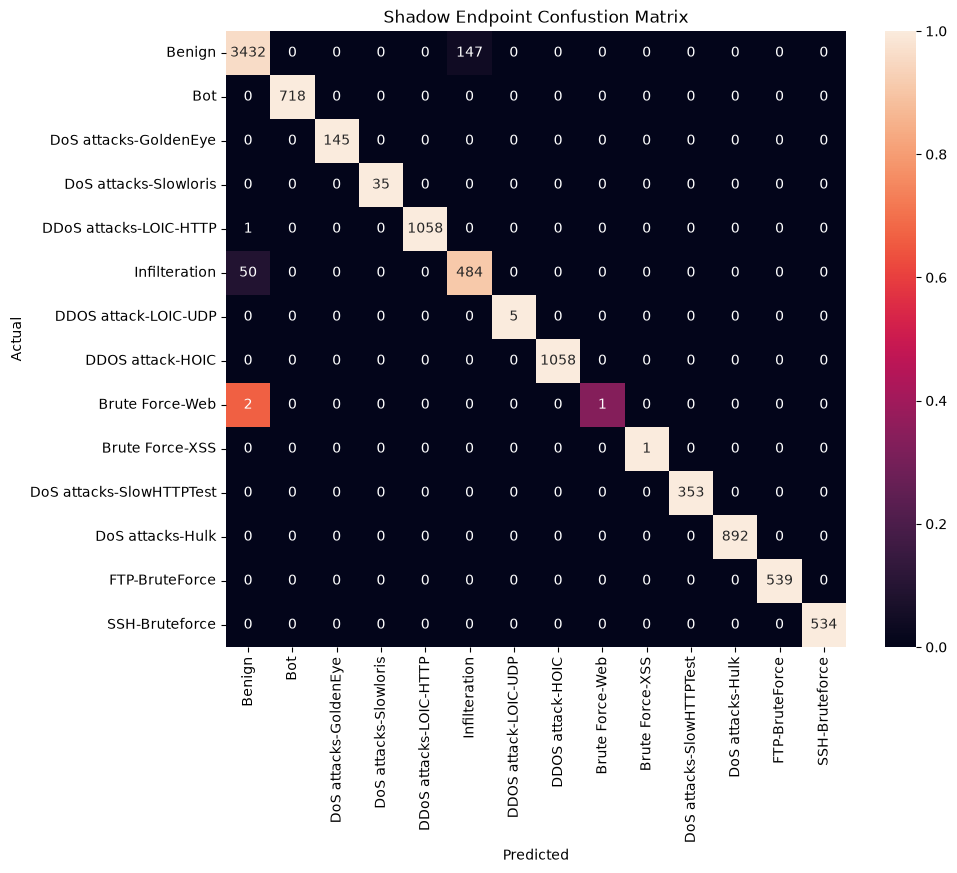

In [25]:
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(shadowdf["Target"], shadowdf["Shadow"])
normalized_cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
clist = [class_list[i] for i in np.sort(shadowdf["Target"].unique())]
sns.heatmap(normalized_cm, ax=ax, annot=cm, fmt="", xticklabels=clist, yticklabels=clist)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Shadow Endpoint Confustion Matrix")
plt.show()

In [26]:
%%time

prodin = []
prodout = []
prodid = []

for f in prodfiles:
    print(f)
    with jsonlines.open(f) as reader:
        for obj in reader:
            try:
                infid = obj["eventMetadata"]["inferenceId"].split(" ")
                prodid.append(int(infid[-1]))

                # input to model
                model_input = base64.b64decode(obj["captureData"]["endpointInput"]["data"])
                prodin.append(np.load(io.BytesIO(model_input))[0].tolist())

                # output from model
                model_output = base64.b64decode(obj["captureData"]["endpointOutput"]["data"])
                prodout.append(np.load(io.BytesIO(model_output))[0])

            except:
                pass

./data/datacapture/AllTraffic/2026/07/16/22/46-18-225-d673978d-1c83-45a9-89c4-669e463e5eb6.jsonl
./data/datacapture/AllTraffic/2026/07/16/22/45-18-033-22a8ee77-ad6c-44c1-a2f4-0ae8b517d371.jsonl
./data/datacapture/AllTraffic/2026/07/16/22/44-18-003-2b4e9c90-6e6d-4879-912c-adeef64ee0f7.jsonl
./data/datacapture/AllTraffic/2026/07/16/22/44-18-518-cae4c48c-64bc-44dc-a44b-416656cb1eb1.jsonl
./data/datacapture/AllTraffic/2026/07/16/22/44-18-129-eaedcdb7-a5e1-4206-be63-5ec8fff773db.jsonl
./data/datacapture/AllTraffic/2026/07/16/22/46-18-769-e8309b60-bd4b-4930-9aec-2ccb10e0f3e4.jsonl
./data/datacapture/AllTraffic/2026/07/16/22/40-14-250-5faa505a-b95d-4d8e-af20-6fa4b4e6dc13.jsonl
./data/datacapture/AllTraffic/2026/07/16/22/47-18-258-361de874-856a-4a15-90c9-71d08e8b9ad6.jsonl


./data/datacapture/AllTraffic/2026/07/16/22/46-18-203-9426eeda-15a2-4805-a064-43faaa3d5b6f.jsonl
./data/datacapture/AllTraffic/2026/07/16/22/45-18-130-a8b30e0b-0a1e-4b03-a074-6205ccc2b924.jsonl
./data/datacapture/AllTraffic/2026/07/16/22/47-18-816-9a697cf8-3d28-4c3d-9692-dcb278e15f50.jsonl
./data/datacapture/AllTraffic/2026/07/16/22/45-18-545-92d27d9f-3d31-4e1d-ba5a-b169d447fd9f.jsonl
./data/datacapture/AllTraffic/2026/07/16/22/47-18-277-a1b7f0d3-6944-4e60-bc01-bc7631121df3.jsonl
CPU times: user 377 ms, sys: 8.87 ms, total: 385 ms
Wall time: 394 ms


In [27]:
proddf = pd.DataFrame(data=prodout, index=prodid, columns=["Prod"])
proddf

,Prod
4093,0
4094,0
4098,4
4103,0
4106,7
...,...
9431,12
9434,14
9438,0
9445,4


In [28]:
# Line up our production model predictions with the true value based on the index
proddf = pd.merge(proddf, holdout["Target"], left_index=True, right_index=True)

In [29]:
acc = accuracy_score(proddf["Target"], proddf["Prod"])
wf1 = f1_score(proddf["Target"], proddf["Prod"], average="weighted")
print(acc, wf1)

0.9795832011001798 0.9807653906810202


In [30]:
print(classification_report(proddf["Target"], proddf["Prod"]))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97      3578
           1       1.00      1.00      1.00       717
           2       1.00      1.00      1.00       145
           3       1.00      1.00      1.00        35
           4       1.00      1.00      1.00      1061
           5       0.76      0.98      0.85       534
           6       0.62      1.00      0.77         5
           7       1.00      1.00      1.00      1058
           8       0.25      0.33      0.29         3
           9       0.00      0.00      0.00         1
          11       1.00      1.00      1.00       353
          12       1.00      1.00      1.00       892
          13       1.00      1.00      1.00       538
          14       1.00      1.00      1.00       533

    accuracy                           0.98      9453
   macro avg       0.83      0.88      0.85      9453
weighted avg       0.98      0.98      0.98      9453



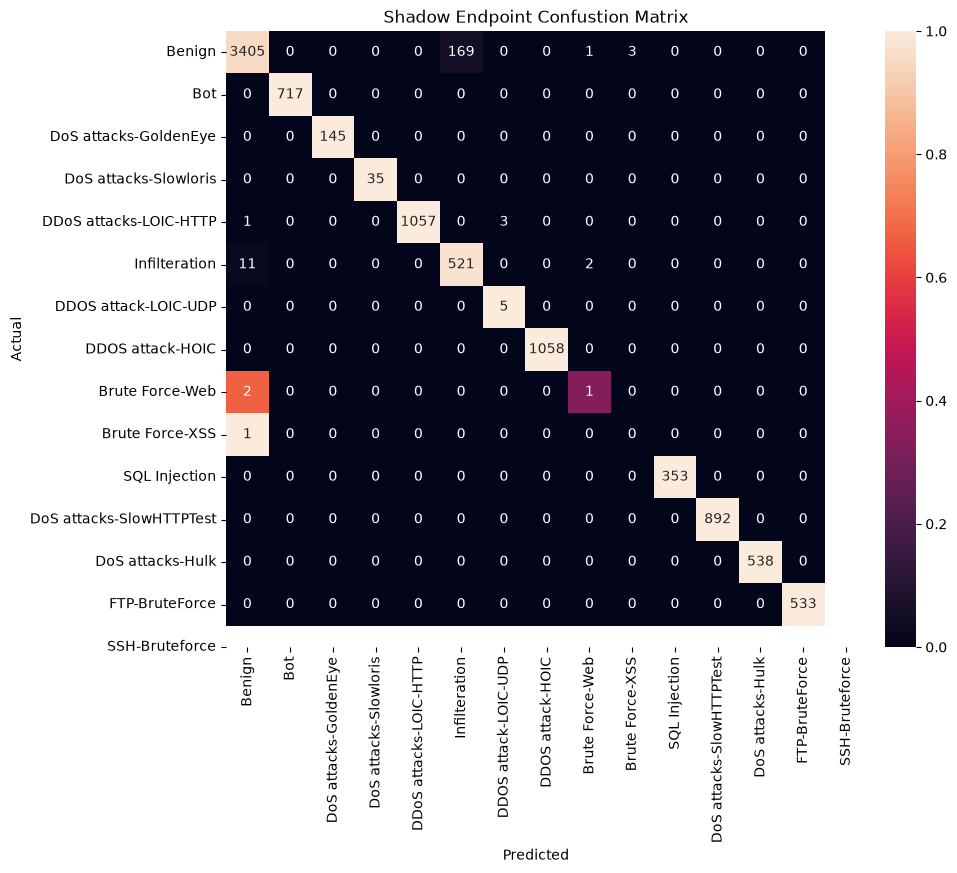

In [31]:
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(proddf["Target"], proddf["Prod"])
normalized_cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(normalized_cm, ax=ax, annot=cm, fmt="", xticklabels=class_list, yticklabels=class_list)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Shadow Endpoint Confustion Matrix")
plt.show()

## End the experiment and promote the shadow model to production
From the above evaluation we've decided that the shadow is ready for production.  We will promote it to production as part of ending the experiment. You can also configure a similar experiment this to run automatically as part of a pipeline, and automatically promote a model if it met your criteria.

In [32]:
sm_client.stop_inference_experiment(
    Name=shadowtestname,
    ModelVariantActions={"Shadow-01": "Promote", "AllTraffic": "Remove"},
    DesiredState="Completed",
    Reason="Shadow variant performed better in validation",
)

{'InferenceExperimentArn': 'arn:aws:sagemaker:us-west-1:729646638167:inference-experiment/shadowinferencetestexistingep-2026-07-16-154016',
 'ResponseMetadata': {'RequestId': 'd3e3e340-ab5f-484f-b675-affa60fb53dd',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': 'd3e3e340-ab5f-484f-b675-affa60fb53dd',
   'strict-transport-security': 'max-age=47304000; includeSubDomains',
   'x-frame-options': 'DENY',
   'content-security-policy': "frame-ancestors 'none'",
   'cache-control': 'no-cache, no-store, must-revalidate',
   'x-content-type-options': 'nosniff',
   'content-type': 'application/x-amz-json-1.1',
   'content-length': '138',
   'date': 'Thu, 16 Jul 2026 22:48:48 GMT'},
  'RetryAttempts': 0}}

In [33]:
# Here we show that the shadow model is now deployed to production
sm_client.describe_endpoint(EndpointName=endpoint_name)

{'EndpointName': 'shadow-api-ep-2026-07-16-153641',
 'EndpointArn': 'arn:aws:sagemaker:us-west-1:729646638167:endpoint/shadow-api-ep-2026-07-16-153641',
 'EndpointConfigName': 'ShadowInferenceT-EpConfig-ZLTJUIrJpMpqSPNA',
 'ProductionVariants': [{'VariantName': 'AllTraffic',
   'DeployedImages': [{'SpecifiedImage': '746614075791.dkr.ecr.us-west-1.amazonaws.com/sagemaker-scikit-learn:1.0-1-cpu-py3',
     'ResolvedImage': '746614075791.dkr.ecr.us-west-1.amazonaws.com/sagemaker-scikit-learn@sha256:c0632f428a4507055882a967c25a53db69273bd366d0d9dbbb2441e241c16170',
     'ResolutionTime': datetime.datetime(2026, 7, 16, 15, 40, 25, 949000, tzinfo=tzlocal())}],
   'CurrentWeight': 1.0,
   'DesiredWeight': 1.0,
   'CurrentInstanceCount': 3,
   'DesiredInstanceCount': 3}],
 'DataCaptureConfig': {'EnableCapture': True,
  'CaptureStatus': 'Started',
  'CurrentSamplingPercentage': 100,
  'DestinationS3Uri': 's3://sagemaker-us-west-1-729646638167/shadow-test/datacapture_test/'},
 'EndpointStatus': '

## Clean Up

In [34]:
def wait_until_complete(test_name):
    print(f"Waiting on shadow test: {test_name}")
    done = False
    while not done:
        shadowtestdescribe = sm_client.describe_inference_experiment(Name=shadowtestname)
        status = shadowtestdescribe["Status"].lower()
        print(f"Status: {status}")
        if status == "completed":
            print("Shadow test is stopped, ok to delete. Exiting Loop.")
            return
        sleep(60)

In [35]:
wait_until_complete(shadowtestname)

Waiting on shadow test: ShadowInferenceTestExistingEP-2026-07-16-154016
Status: stopping


Status: stopping


Status: stopping


Status: stopping


Status: completed
Shadow test is stopped, ok to delete. Exiting Loop.


In [36]:
sm_client.delete_inference_experiment(Name=shadowtestname)
sm_client.delete_endpoint(EndpointName=endpoint_name)

{'ResponseMetadata': {'RequestId': '2ab5757d-3fed-4531-97db-b747fa1eb0f4',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': '2ab5757d-3fed-4531-97db-b747fa1eb0f4',
   'strict-transport-security': 'max-age=47304000; includeSubDomains',
   'x-frame-options': 'DENY',
   'content-security-policy': "frame-ancestors 'none'",
   'cache-control': 'no-cache, no-store, must-revalidate',
   'x-content-type-options': 'nosniff',
   'content-type': 'application/x-amz-json-1.1',
   'date': 'Thu, 16 Jul 2026 22:52:49 GMT',
   'content-length': '0'},
  'RetryAttempts': 0}}

# References

* A Realistic Cyber Defense Dataset (CSE-CIC-IDS2018) - https://registry.opendata.aws/cse-cic-ids2018/
* AIM362 - Re:Invent 2019 SageMaker Debugger and Model Monitor - https://github.com/aws-samples/reinvent2019-aim362-sagemaker-debugger-model-monitor

## Notebook CI Test Results

This notebook was tested in multiple regions. The test results are as follows, except for us-west-2 which is shown at the top of the notebook.

![This us-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-1/deploy_and_monitor|sm-shadow_variant_shadow_api|sm-shadow_variant_shadow_api.ipynb)

![This us-east-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-2/deploy_and_monitor|sm-shadow_variant_shadow_api|sm-shadow_variant_shadow_api.ipynb)

![This us-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-1/deploy_and_monitor|sm-shadow_variant_shadow_api|sm-shadow_variant_shadow_api.ipynb)

![This ca-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ca-central-1/deploy_and_monitor|sm-shadow_variant_shadow_api|sm-shadow_variant_shadow_api.ipynb)

![This sa-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/sa-east-1/deploy_and_monitor|sm-shadow_variant_shadow_api|sm-shadow_variant_shadow_api.ipynb)

![This eu-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-1/deploy_and_monitor|sm-shadow_variant_shadow_api|sm-shadow_variant_shadow_api.ipynb)

![This eu-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-2/deploy_and_monitor|sm-shadow_variant_shadow_api|sm-shadow_variant_shadow_api.ipynb)

![This eu-west-3 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-3/deploy_and_monitor|sm-shadow_variant_shadow_api|sm-shadow_variant_shadow_api.ipynb)

![This eu-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-central-1/deploy_and_monitor|sm-shadow_variant_shadow_api|sm-shadow_variant_shadow_api.ipynb)

![This eu-north-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-north-1/deploy_and_monitor|sm-shadow_variant_shadow_api|sm-shadow_variant_shadow_api.ipynb)

![This ap-southeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-1/deploy_and_monitor|sm-shadow_variant_shadow_api|sm-shadow_variant_shadow_api.ipynb)

![This ap-southeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-2/deploy_and_monitor|sm-shadow_variant_shadow_api|sm-shadow_variant_shadow_api.ipynb)

![This ap-northeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-1/deploy_and_monitor|sm-shadow_variant_shadow_api|sm-shadow_variant_shadow_api.ipynb)

![This ap-northeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-2/deploy_and_monitor|sm-shadow_variant_shadow_api|sm-shadow_variant_shadow_api.ipynb)

![This ap-south-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-south-1/deploy_and_monitor|sm-shadow_variant_shadow_api|sm-shadow_variant_shadow_api.ipynb)
